In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [10]:
df = pd.read_csv('Student Social Media And Mental Health Impact.csv')

In [5]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


## **EDA**

In [6]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [7]:
df.shape

(5000, 13)

In [8]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(2)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   str    
 2   Country                  5000 non-null   str    
 3   Academic_Level           5000 non-null   str    
 4   Most_Used_Platform       5000 non-null   str    
 5   Purpose_Of_Use           5000 non-null   str    
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   str    
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), str(6)
memory usage: 507.9 KB


In [11]:
categorical_col = df[['Gender','Country','Academic_Level','Most_Used_Platform','Purpose_Of_Use','Stress_Level']]

In [12]:
display(categorical_col)


,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Stress_Level
0,Male,Other,Undergraduate,Facebook,Networking,Medium
1,Female,Other,Graduate,LinkedIn,Education,Low
2,Male,Canada,Undergraduate,Instagram,Entertainment,Medium
3,Male,Other,High School,Snapchat,Entertainment,Very High
4,Female,Other,Graduate,Facebook,Networking,Very High
...,...,...,...,...,...,...
4995,Female,Other,High School,YouTube,Education,Low
4996,Female,Other,High School,YouTube,Education,Very High
4997,Female,India,Undergraduate,LinkedIn,Education,Medium
4998,Male,Other,High School,Instagram,Entertainment,Medium


In [13]:
df['Stress_Level'].value_counts()

Stress_Level
Very High    1621
High         1440
Medium       1295
Low           644
Name: count, dtype: int64

In [14]:
df['Gender'].value_counts()

Gender
Male      2635
Female    2365
Name: count, dtype: int64

In [15]:
df['Country'].value_counts() 

Country
Other         1880
India          389
USA            355
Canada         230
Australia      198
              ... 
Montenegro       1
Bosnia           1
Kuwait           1
Yemen            1
Syria            1
Name: count, Length: 111, dtype: int64

In [16]:
df['Academic_Level'].value_counts()

Academic_Level
Undergraduate    3632
Graduate          918
High School       450
Name: count, dtype: int64

In [17]:
df['Most_Used_Platform'].value_counts()

Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      523
YouTube       491
Twitter       462
Snapchat      420
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

In [18]:
df['Purpose_Of_Use'].value_counts()

Purpose_Of_Use
Entertainment    2552
Education        1094
Networking        793
News              561
Name: count, dtype: int64

In [23]:
numerical_cols = df[ [
    'Age',
    'Avg_Daily_Usage_Hours',
    'Daily_Unlocks',
    'Study_Hours',
    'Physical_Activity_Hours',
    'Sleep_Hours_Per_Night',
    'Mental_Health_Score'
]]

display(numerical_cols)

# Histograms

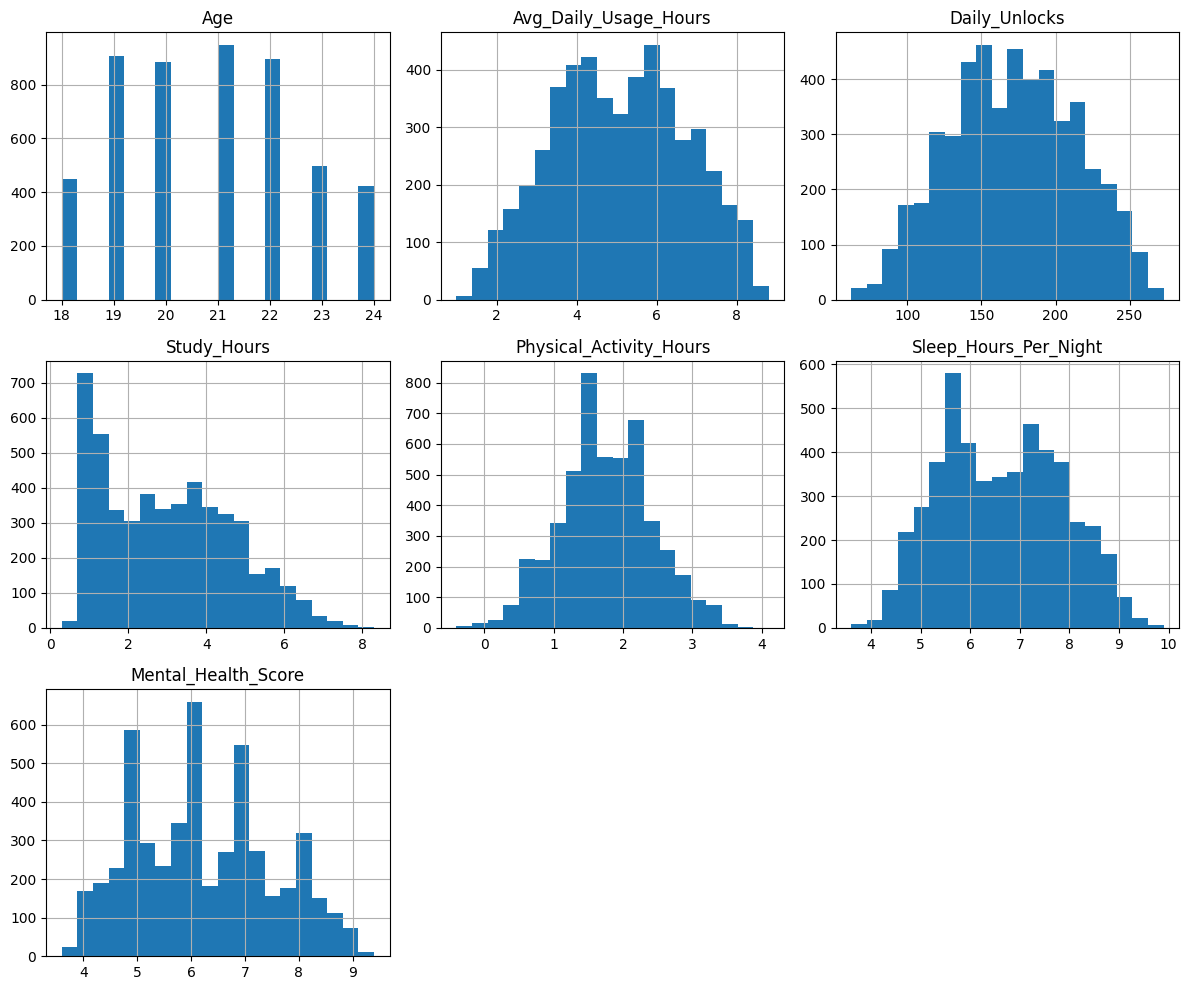

In [28]:
df[numeric_cols].hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(14, 14))

for i, col in enumerate(numeric_cols):
    axes[i // 2, i % 2].hist(df[col], bins=20)
    axes[i // 2, i % 2].set_title(col)
    axes[i // 2, i % 2].set_xlabel(col)
    axes[i // 2, i % 2].set_ylabel('Frequency')
    axes[i // 2, i % 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## - physical activity hours and study hours have outliers
## - study hours column is right skewed 

# Boxplot

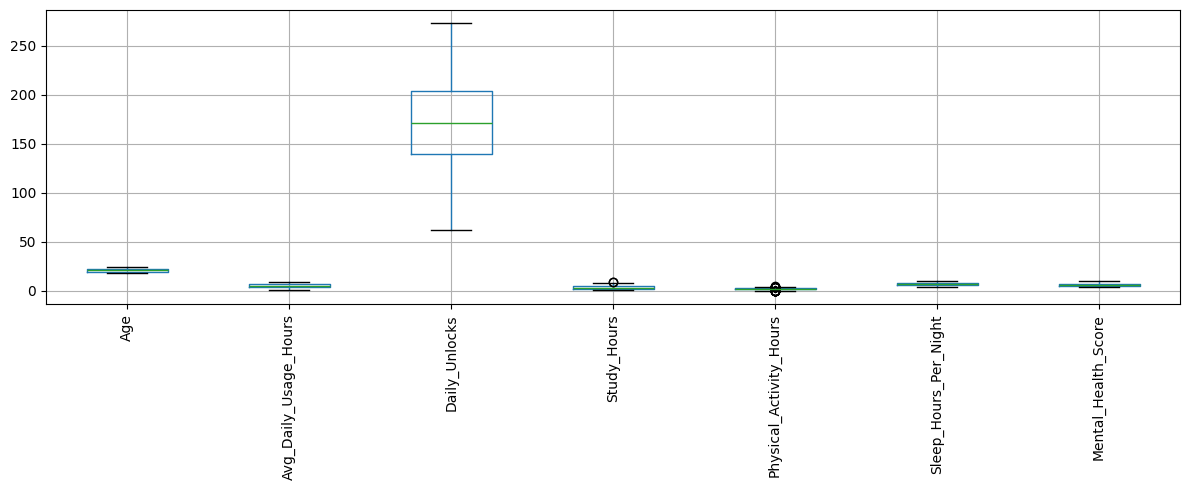

In [34]:
plt.figure(figsize=(12, 5))

df[numeric_cols].boxplot()

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

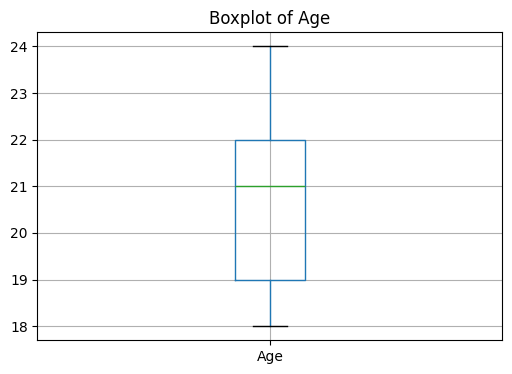

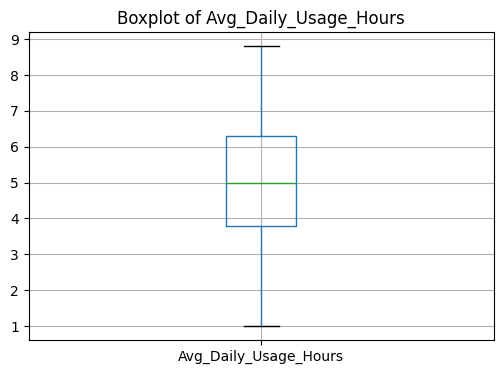

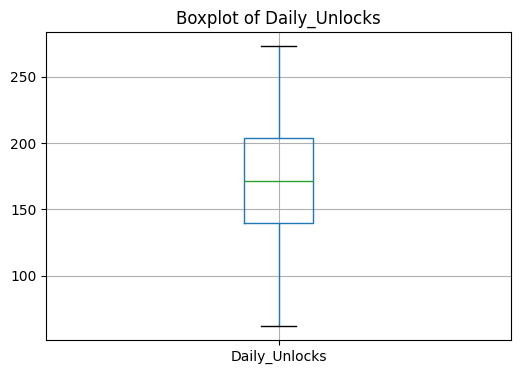

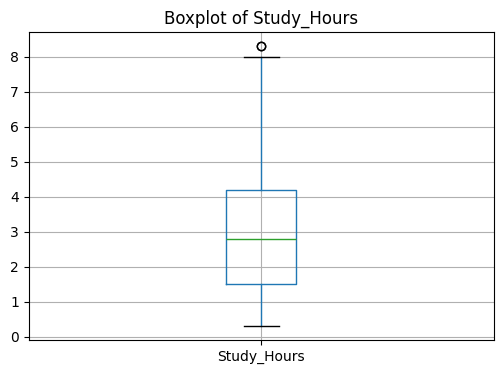

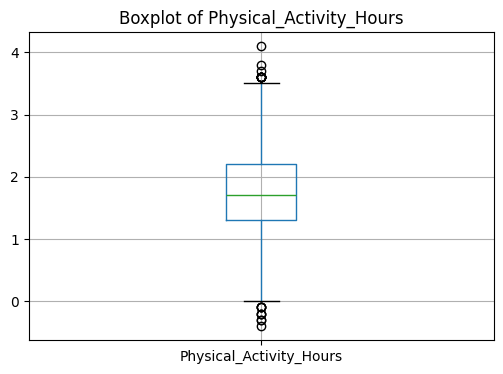

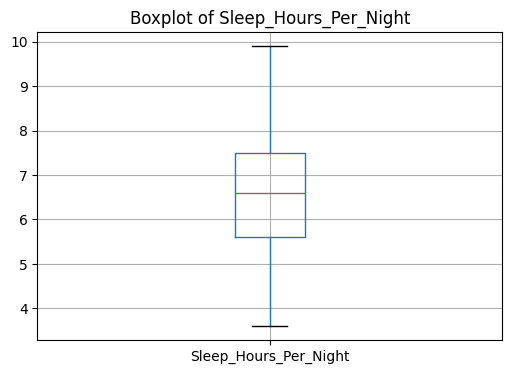

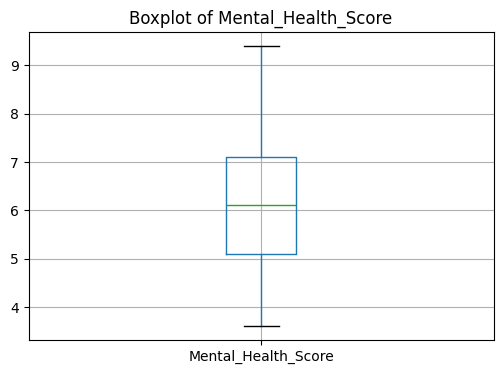

In [36]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    df.boxplot(column=col)
    plt.title(f'Boxplot of {col}')
    plt.show()

# Correlation

In [37]:
corr = df[numeric_cols].corr()

corr

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
Age,1.000000,-0.070092,-0.074488,0.083109,0.012984,0.088681,0.100785
Avg_Daily_Usage_Hours,-0.070092,1.000000,0.960187,-0.878645,-0.625707,-0.808388,-0.816453
Daily_Unlocks,-0.074488,0.960187,1.000000,-0.853397,-0.602828,-0.781823,-0.790851
Study_Hours,0.083109,-0.878645,-0.853397,1.000000,0.560532,0.730136,0.752626
Physical_Activity_Hours,0.012984,-0.625707,-0.602828,0.560532,1.000000,0.507851,0.521374
Sleep_Hours_Per_Night,0.088681,-0.808388,-0.781823,0.730136,0.507851,1.000000,0.766430
Mental_Health_Score,0.100785,-0.816453,-0.790851,0.752626,0.521374,0.766430,1.000000


This tells us that:

* **Age** does not have a strong relationship with any of the other variables, as its correlation values are mostly close to **0 or around 0.1 at         maximum**.

* **Avg_Daily_Usage_Hours** has strong relationships with several variables. It has an extremely strong positive correlation with **Daily_Unlocks**      while it has strong negative correlations with **Study_Hours** as abg daily use and daily unloacks are kinda same so we might be able to remove one    from them in future

* **Daily_Unlocks** has strong pos/neg relation with most variables

* **Study_Hours** has weak relation with age and a noticeable relationship with **Physical_Activity_Hours, Sleep_Hours_Per_Night,** and
  **Mental_Health_Score**.

* **Physical_Activity_Hours** shows a similar pattern to **Study_Hours**, having noticeable relationships with **Study_Hours, Sleep_Hours_Per_Night,**     and **Mental_Health_Score**.

* **Sleep_Hours_Per_Night** is related to **Age, Study_Hours, Physical_Activity_Hours,** and **Mental_Health_Score** with a pos crr and it has no         relation with age

* AGE IS POTENTIALLY WEAK FEATURE


## CORELATION ANALYSIS FOR THE CATEGORICAL FEATURES

* lets do a boxplot and a categorical relationship analysis and use boxploy for that
*   stress lvl and mental health score

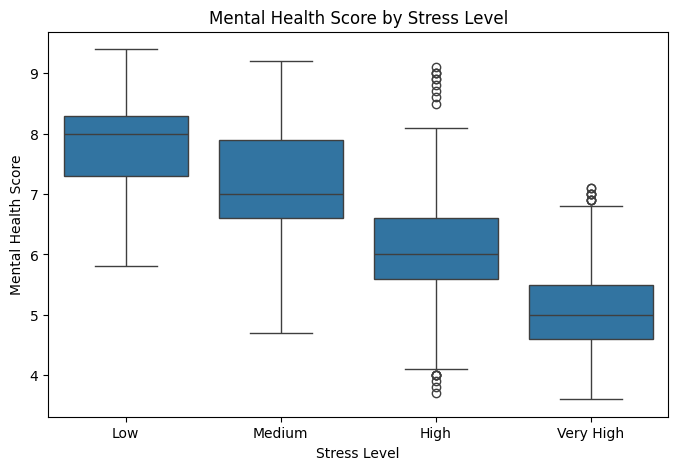

In [12]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Stress_Level',
    y='Mental_Health_Score',
    order=['Low', 'Medium', 'High', 'Very High']
)

plt.title('Mental Health Score by Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Mental Health Score')

plt.show()

* here in very high and high category we can see some outliers 

In [13]:
df.groupby('Stress_Level')['Mental_Health_Score'].agg(
    ['mean', 'median', 'count']
)

,mean,median,count
Stress_Level,,,
High,6.025417,6.0,1440
Low,7.840217,8.0,644
Medium,7.135907,7.0,1295
Very High,5.051326,5.0,1621


* Gender vs Mental Health Score

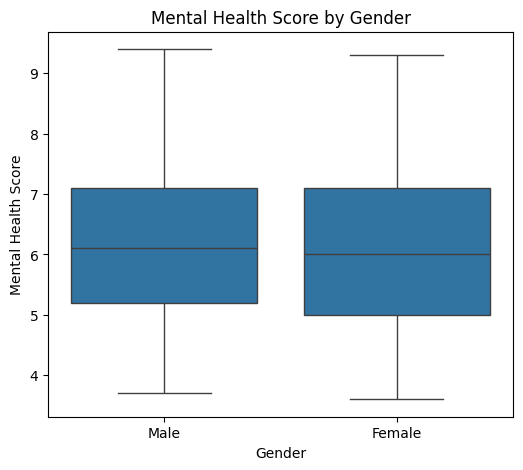

In [14]:
plt.figure(figsize=(6, 5))

sns.boxplot(
    data=df,
    x='Gender',
    y='Mental_Health_Score'
)

plt.title('Mental Health Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Mental Health Score')

plt.show()

In [15]:
df.groupby('Gender')['Mental_Health_Score'].agg(
    ['mean', 'median', 'count']
)

,mean,median,count
Gender,,,
Female,6.185285,6.0,2365
Male,6.271992,6.1,2635


* we can drop this one during feature selection as the relation aint that strong because the box is overlapping eachother and there isnt
much difference between the two

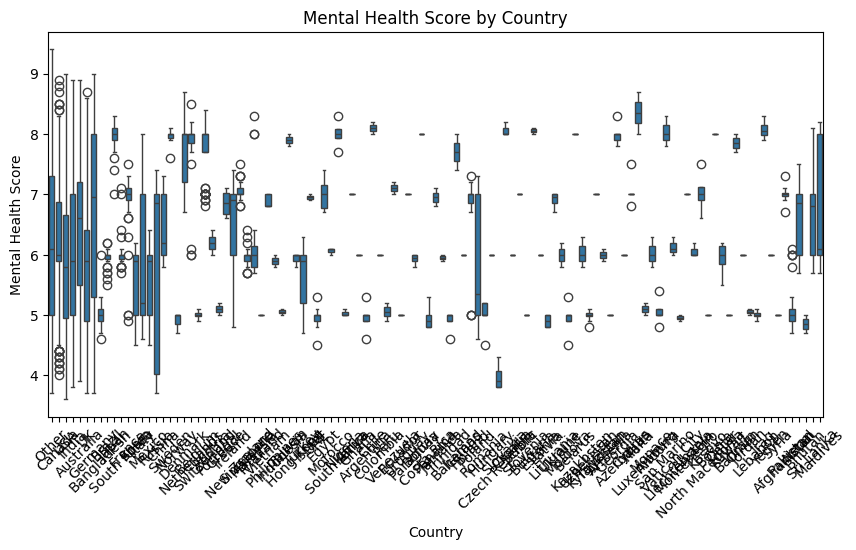

In [18]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x='Country',
    y='Mental_Health_Score'
)

plt.xticks(rotation=45)
plt.title('Mental Health Score by Country')
plt.xlabel('Country')
plt.ylabel('Mental Health Score')

plt.show()

In [19]:
df.groupby('Country')['Mental_Health_Score'].agg(
    ['mean', 'median', 'count']
).sort_values('mean')

,mean,median,count
Country,,,
Czech Republic,3.975000,3.90,4
Bhutan,4.850000,4.85,2
Latvia,4.900000,4.90,4
Trinidad,4.900000,5.00,4
Norway,4.916667,5.00,6
...,...,...,...
Bulgaria,8.050000,8.05,2
Slovakia,8.066667,8.00,3
Iraq,8.075000,8.05,4


In [20]:
df['Country'].value_counts()

Country
Other         1880
India          389
USA            355
Canada         230
Australia      198
              ... 
Montenegro       1
Bosnia           1
Kuwait           1
Yemen            1
Syria            1
Name: count, Length: 111, dtype: int64

In [21]:
df['Country'].nunique()

111

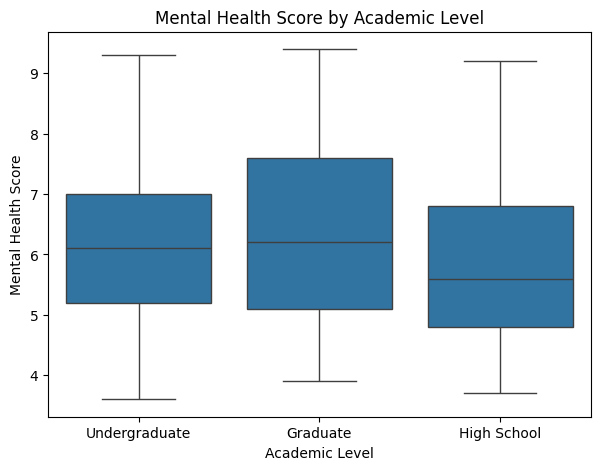

In [22]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x='Academic_Level',
    y='Mental_Health_Score'
)

plt.title('Mental Health Score by Academic Level')
plt.xlabel('Academic Level')
plt.ylabel('Mental Health Score')

plt.show()

In [23]:
df.groupby('Academic_Level')['Mental_Health_Score'].agg(
    ['mean', 'median', 'count']
)

,mean,median,count
Academic_Level,,,
Graduate,6.391176,6.2,918
High School,5.864000,5.6,450
Undergraduate,6.235958,6.1,3632


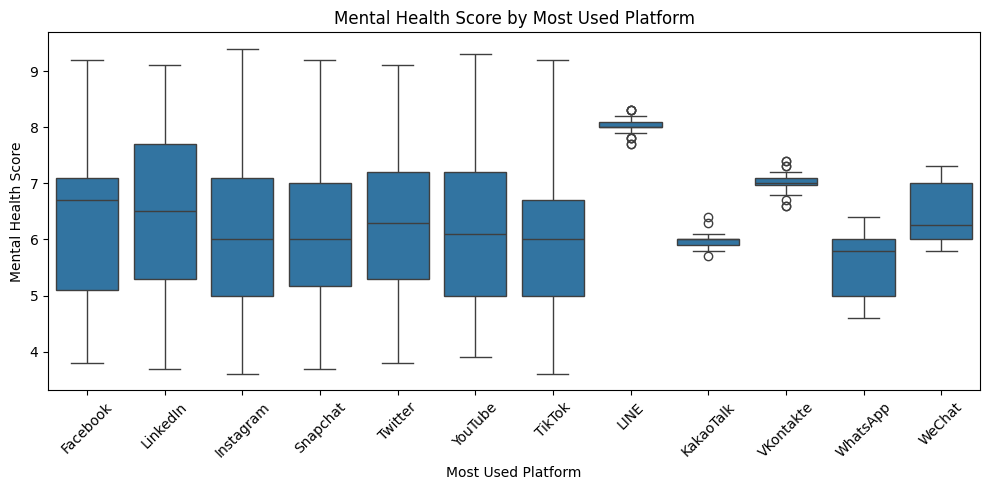

In [24]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x='Most_Used_Platform',
    y='Mental_Health_Score'
)

plt.xticks(rotation=45)
plt.title('Mental Health Score by Most Used Platform')
plt.xlabel('Most Used Platform')
plt.ylabel('Mental Health Score')

plt.tight_layout()
plt.show()

In [25]:
df.groupby('Most_Used_Platform')['Mental_Health_Score'].agg(
    ['mean', 'median', 'count']
).sort_values('mean')

,mean,median,count
Most_Used_Platform,,,
WhatsApp,5.578286,5.80,175
KakaoTalk,5.983333,6.00,36
TikTok,5.993355,6.00,918
Snapchat,6.123095,6.00,420
Instagram,6.194071,6.00,1130
YouTube,6.216497,6.10,491
Twitter,6.346753,6.30,462
Facebook,6.398331,6.70,719
LinkedIn,6.482600,6.50,523


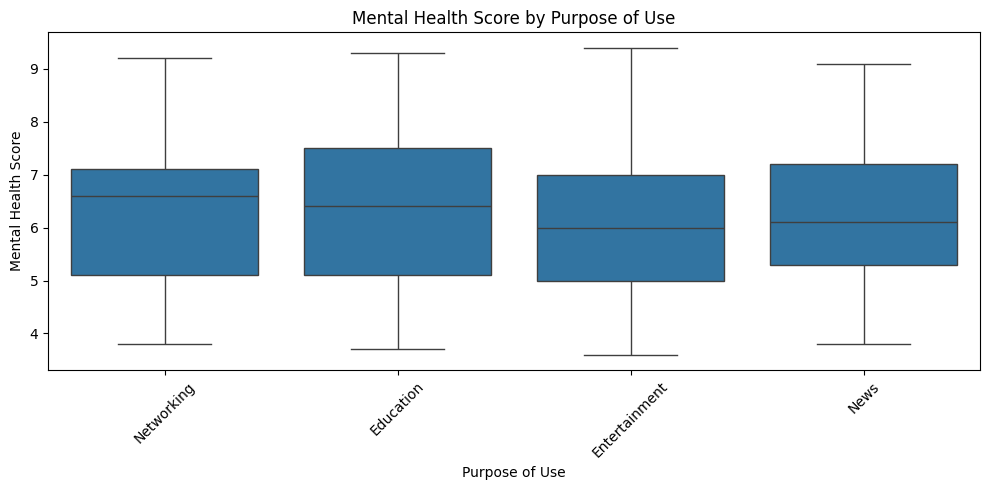

In [26]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x='Purpose_Of_Use',
    y='Mental_Health_Score'
)

plt.xticks(rotation=45)

plt.title('Mental Health Score by Purpose of Use')
plt.xlabel('Purpose of Use')
plt.ylabel('Mental Health Score')

plt.tight_layout()
plt.show()

# Final conclusion


* age , gender, country, most used plat form and purpose of use -- **THESE ARE WEAK FEATURES**
* remaining are strong ones

# Data cleaning and Feature selection
